In [1]:
import sys 
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sys.executable, np.__version__, pd.__version__

('/opt/anaconda3/envs/btpredict/bin/python', '2.2.6', '2.3.2')

In [2]:
from pathlib import Path
print("CWD:", Path.cwd())
print("Files here:", [p.name for p in Path('.').glob('*')][:10])

CWD: /Users/nicklynch/Documents/code/btpredict/SDS-CP038-banktermpredict_lynch
Files here: ['advanced', 'model_df', '.DS_Store', 'requirements.txt', 'bank-full.csv', 'beginner', 'README.md', '.gitignore', 'CONTRIBUTING.md', '.ipynb_checkpoints']


In [3]:
df = Path("bank-full.csv")
if not df.exists():
    raise FileNotFoundError("File not found. Please place it in the same folder as this notebook.")

df = pd.read_csv(df, sep=";")
df.head()

,age,job,marital,education,default,balance,housing,loan,contact,day,month,duration,campaign,pdays,previous,poutcome,y
0,58,management,married,tertiary,no,2143,yes,no,unknown,5,may,261,1,-1,0,unknown,no
1,44,technician,single,secondary,no,29,yes,no,unknown,5,may,151,1,-1,0,unknown,no
2,33,entrepreneur,married,secondary,no,2,yes,yes,unknown,5,may,76,1,-1,0,unknown,no
3,47,blue-collar,married,unknown,no,1506,yes,no,unknown,5,may,92,1,-1,0,unknown,no
4,33,unknown,single,unknown,no,1,no,no,unknown,5,may,198,1,-1,0,unknown,no


In [4]:
df = df.rename(columns={
    "marital": "marital_status",
    "housing": "active_home_loan",
    "default": "has_credit_default",
    "loan": "active_personal_loan",
    "contact": "call_contact_type",
    "day": "last_contact_dom",
    "month": "last_contact_month",
    "duration": "last_contact_duration",
    "campaign": "total_contacts",
    "pdays": "days_since_last_contact",
    "previous": "historical_contacts",
    "poutcome": "prior_campaign_results"
})

🛠️ 1. Project Setup & Data Loading
Q: How did you set up your project environment and manage dependencies?

A:

Q: What steps did you take to load and inspect the dataset?

A:

In [5]:
df["y"] = df["y"].map({"no": 0, "yes": 1}).astype(int)
df["active_home_loan"] = df["active_home_loan"].map({"no": 0, "yes": 1}).astype(int)
df["has_credit_default"] = df["has_credit_default"].map({"no": 0, "yes": 1}).astype(int)
df["active_personal_loan"] = df["active_personal_loan"].map({"no": 0, "yes": 1}).astype(int)

df["last_contact_dom"] = df["last_contact_dom"].astype(str)

# Verify conversion
print(df["y"].unique())

[0 1]


In [6]:
df_info = df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 45211 entries, 0 to 45210
Data columns (total 17 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   age                      45211 non-null  int64 
 1   job                      45211 non-null  object
 2   marital_status           45211 non-null  object
 3   education                45211 non-null  object
 4   has_credit_default       45211 non-null  int64 
 5   balance                  45211 non-null  int64 
 6   active_home_loan         45211 non-null  int64 
 7   active_personal_loan     45211 non-null  int64 
 8   call_contact_type        45211 non-null  object
 9   last_contact_dom         45211 non-null  object
 10  last_contact_month       45211 non-null  object
 11  last_contact_duration    45211 non-null  int64 
 12  total_contacts           45211 non-null  int64 
 13  days_since_last_contact  45211 non-null  int64 
 14  historical_contacts      45211 non-nul

In [7]:
# Quick look at data types and non-null counts
dtype_summary = df.dtypes.to_frame("dtype")
dtype_summary["non_null_count"] = df.notna().sum()
dtype_summary["unique_values"] = df.nunique()

display(dtype_summary)

print(f"Total rows: {len(df):,}")

,dtype,non_null_count,unique_values
age,int64,45211,77
job,object,45211,12
marital_status,object,45211,3
education,object,45211,4
has_credit_default,int64,45211,2
balance,int64,45211,7168
active_home_loan,int64,45211,2
active_personal_loan,int64,45211,2
call_contact_type,object,45211,3
last_contact_dom,object,45211,31


Total rows: 45,211


In [8]:
print('Missing values:')
display(df.isnull().sum())

print('Number of duplicate rows in features:', df.duplicated().sum())

print('Data types:')
print(df.dtypes)

Missing values:


age                        0
job                        0
marital_status             0
education                  0
has_credit_default         0
balance                    0
active_home_loan           0
active_personal_loan       0
call_contact_type          0
last_contact_dom           0
last_contact_month         0
last_contact_duration      0
total_contacts             0
days_since_last_contact    0
historical_contacts        0
prior_campaign_results     0
y                          0
dtype: int64

Number of duplicate rows in features: 0
Data types:
age                         int64
job                        object
marital_status             object
education                  object
has_credit_default          int64
balance                     int64
active_home_loan            int64
active_personal_loan        int64
call_contact_type          object
last_contact_dom           object
last_contact_month         object
last_contact_duration       int64
total_contacts              int64
days_since_last_contact     int64
historical_contacts         int64
prior_campaign_results     object
y                           int64
dtype: object


In [9]:
y = "y"

# Separate categorical and numeric columns
categorical_cols = df.select_dtypes(include="object").columns
numeric_cols = df.select_dtypes(include="number").columns

for col in categorical_cols:
    print(f"\nColumn: {col}")
    print("Unique values:", df[col].unique())
    print("Value counts:")
    print(df[col].value_counts())
    print("-" * 40)

# summary
print(f"\nTotal categorical columns: {len(categorical_cols)}")


Column: job
Unique values: ['management' 'technician' 'entrepreneur' 'blue-collar' 'unknown'
 'retired' 'admin.' 'services' 'self-employed' 'unemployed' 'housemaid'
 'student']
Value counts:
job
blue-collar      9732
management       9458
technician       7597
admin.           5171
services         4154
retired          2264
self-employed    1579
entrepreneur     1487
unemployed       1303
housemaid        1240
student           938
unknown           288
Name: count, dtype: int64
----------------------------------------

Column: marital_status
Unique values: ['married' 'single' 'divorced']
Value counts:
marital_status
married     27214
single      12790
divorced     5207
Name: count, dtype: int64
----------------------------------------

Column: education
Unique values: ['tertiary' 'secondary' 'unknown' 'primary']
Value counts:
education
secondary    23202
tertiary     13301
primary       6851
unknown       1857
Name: count, dtype: int64
----------------------------------------

Colum

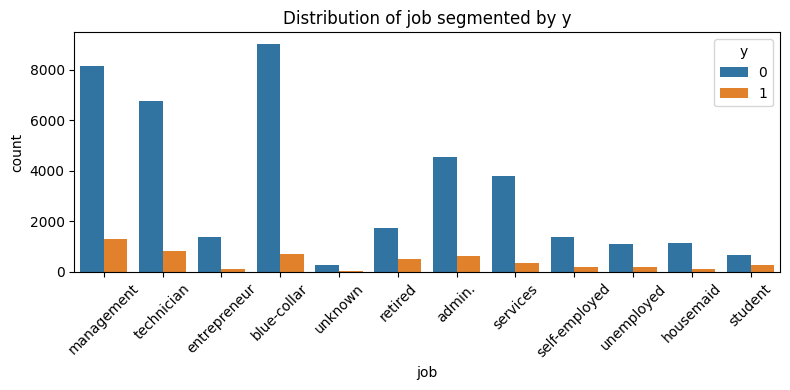

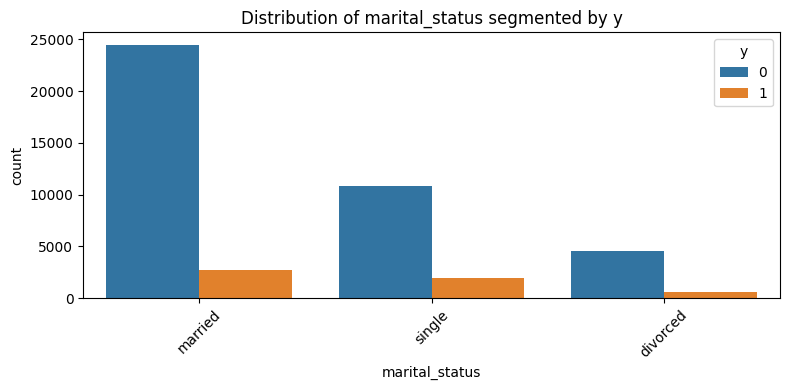

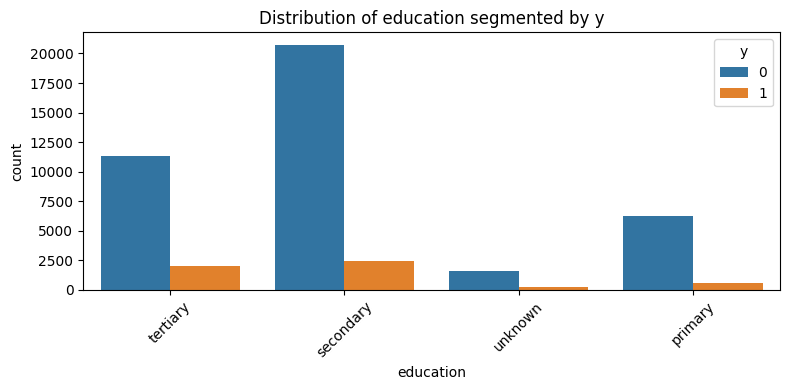

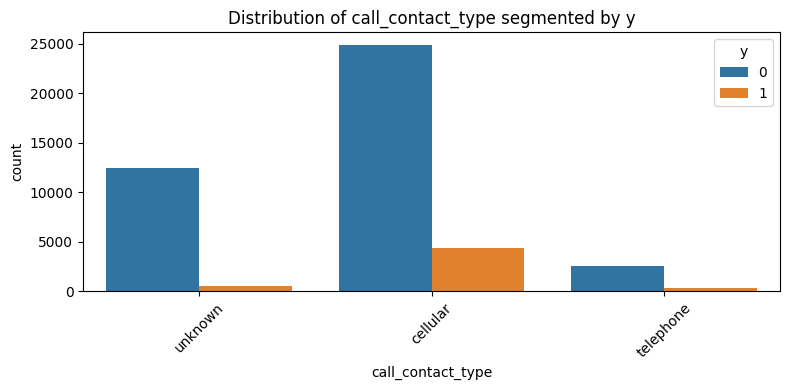

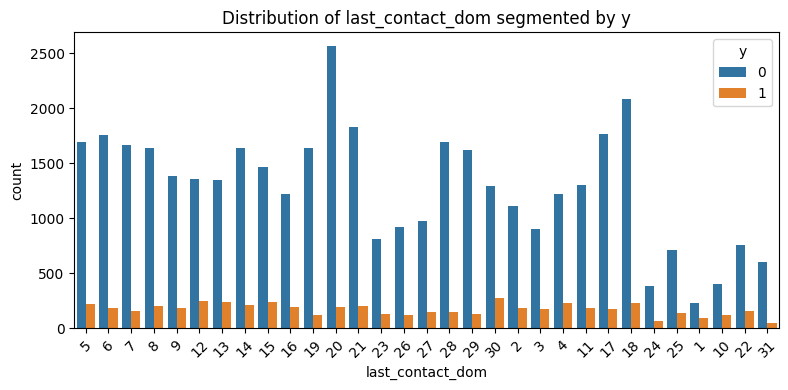

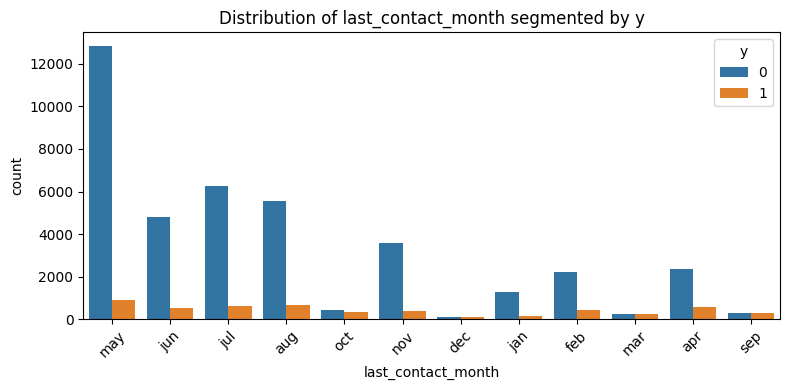

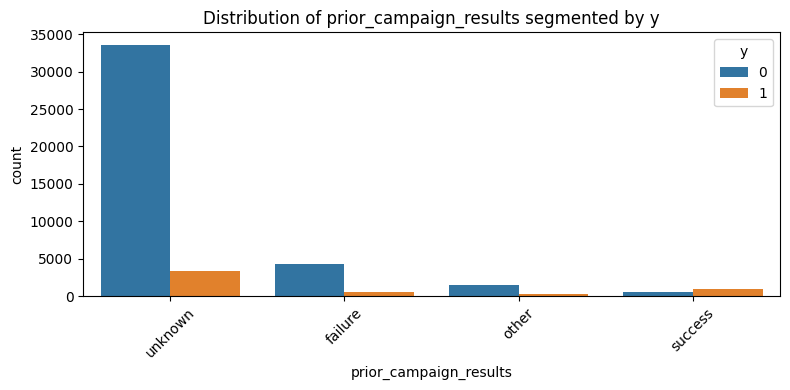

/var/folders/xs/24ttpwt936jdywkx2py8p8hw0000gn/T/ipykernel_63977/3197091921.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)


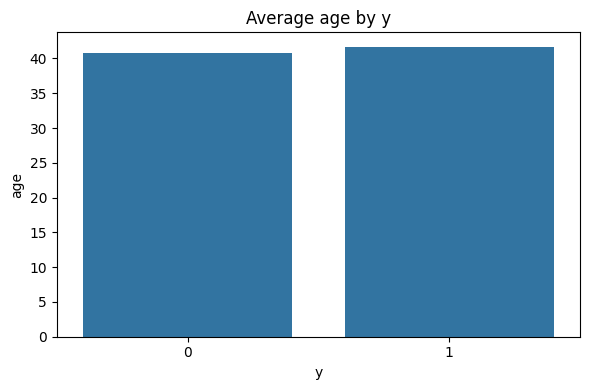

/var/folders/xs/24ttpwt936jdywkx2py8p8hw0000gn/T/ipykernel_63977/3197091921.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)


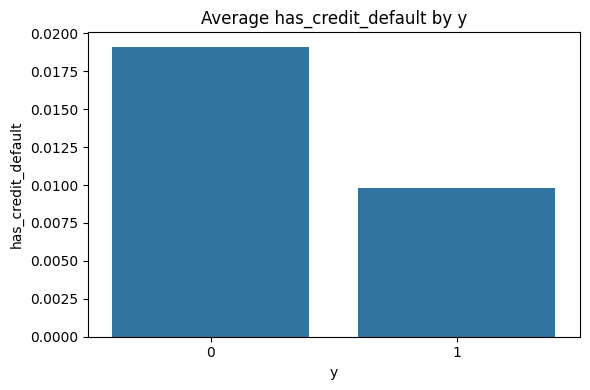

/var/folders/xs/24ttpwt936jdywkx2py8p8hw0000gn/T/ipykernel_63977/3197091921.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)


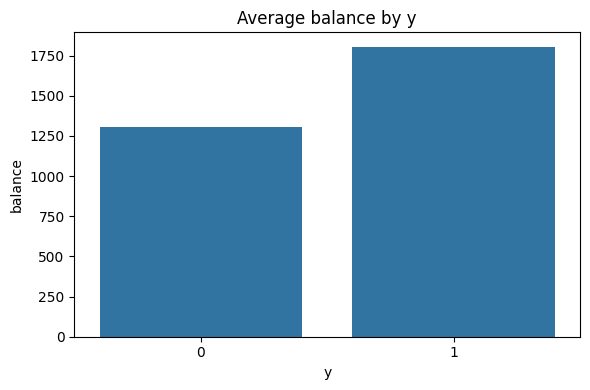

/var/folders/xs/24ttpwt936jdywkx2py8p8hw0000gn/T/ipykernel_63977/3197091921.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)


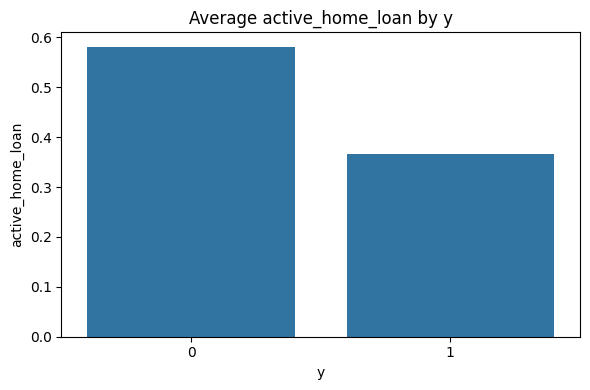

/var/folders/xs/24ttpwt936jdywkx2py8p8hw0000gn/T/ipykernel_63977/3197091921.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)


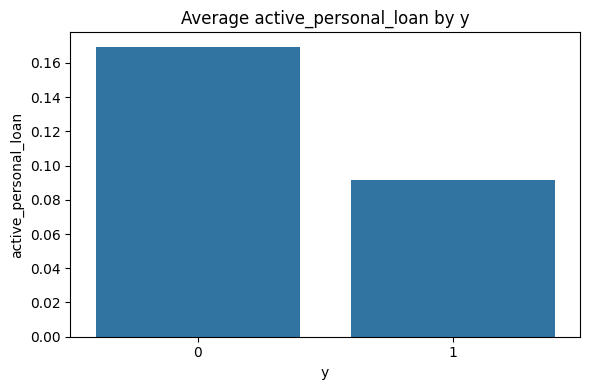

/var/folders/xs/24ttpwt936jdywkx2py8p8hw0000gn/T/ipykernel_63977/3197091921.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)


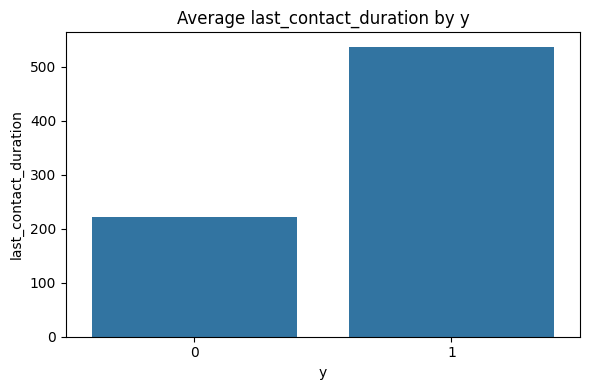

/var/folders/xs/24ttpwt936jdywkx2py8p8hw0000gn/T/ipykernel_63977/3197091921.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)


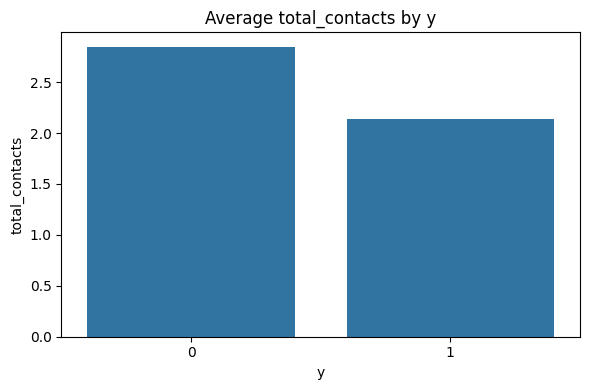

/var/folders/xs/24ttpwt936jdywkx2py8p8hw0000gn/T/ipykernel_63977/3197091921.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)


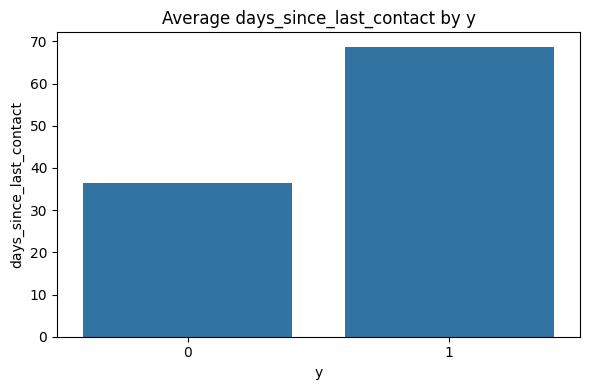

/var/folders/xs/24ttpwt936jdywkx2py8p8hw0000gn/T/ipykernel_63977/3197091921.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)


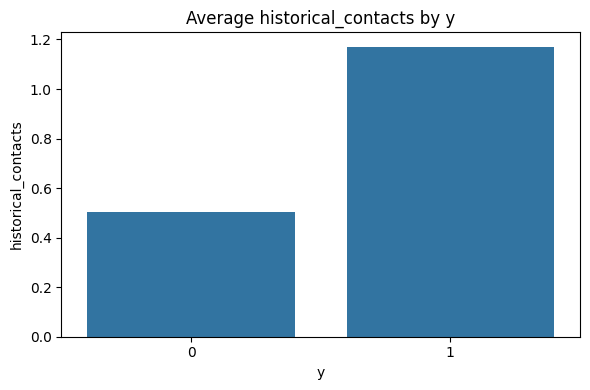

/var/folders/xs/24ttpwt936jdywkx2py8p8hw0000gn/T/ipykernel_63977/3197091921.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)


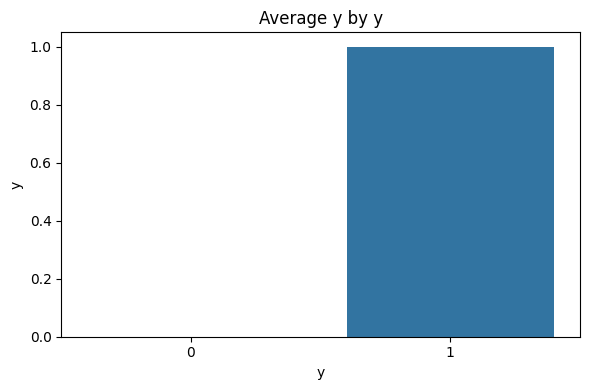

In [10]:
# --- Plot categorical features ---
for col in categorical_cols:
    plt.figure(figsize=(8, 4))
    sns.countplot(data=df, x=col, hue=y)
    plt.title(f"Distribution of {col} segmented by {y}")
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()

# --- Plot numerical features ---
for col in numeric_cols:
    plt.figure(figsize=(6, 4))
    sns.barplot(data=df, x=y, y=col, estimator="mean", ci=None)
    plt.title(f"Average {col} by {y}")
    plt.tight_layout()
    plt.show()

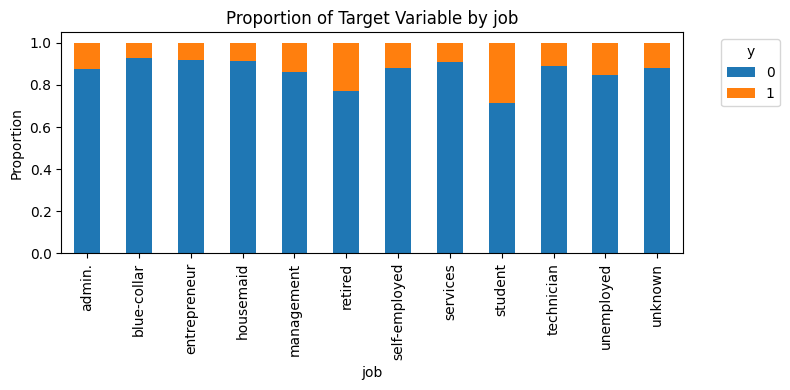

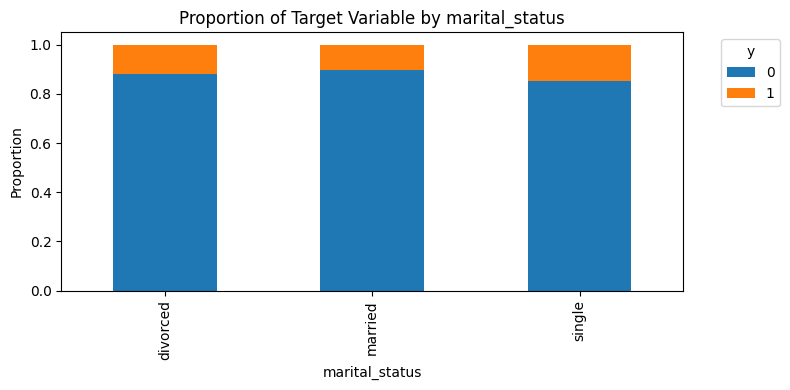

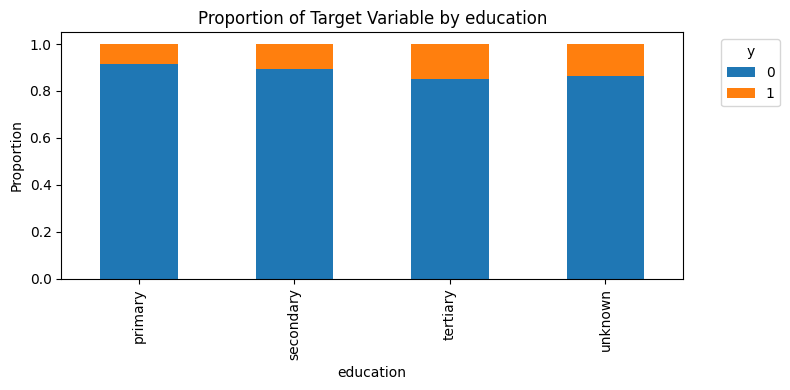

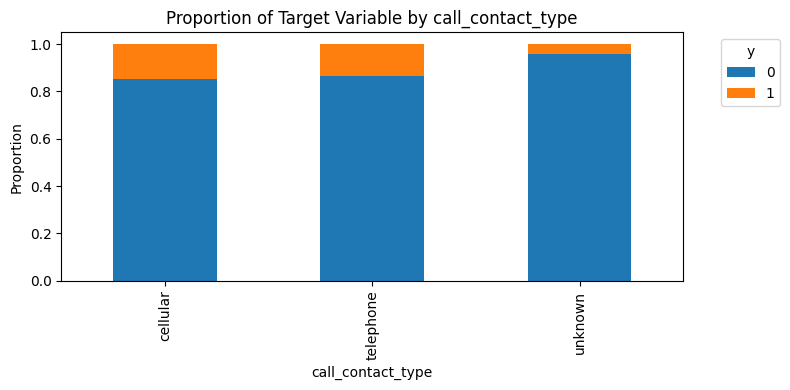

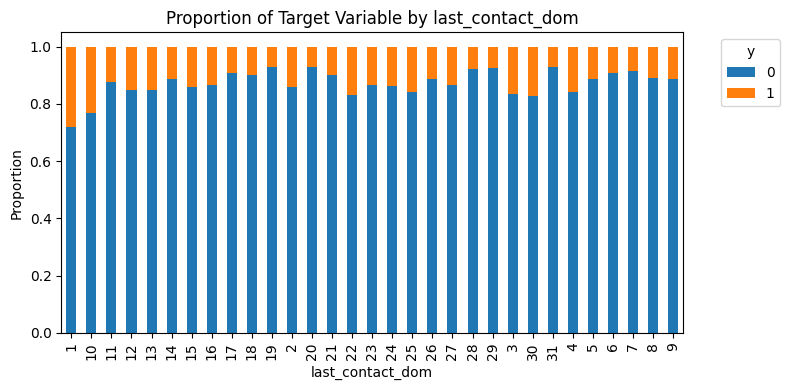

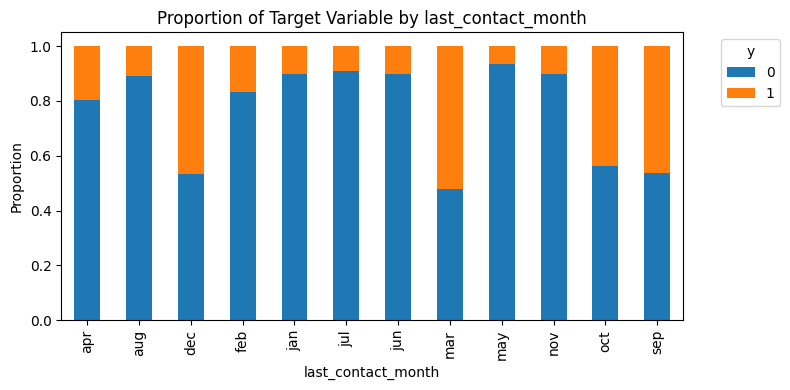

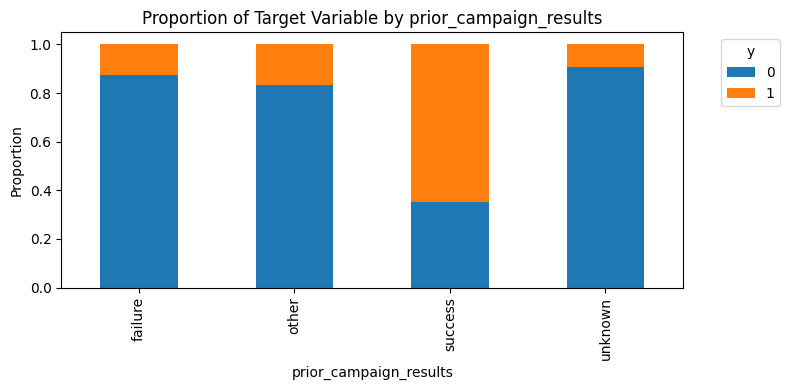

In [11]:
for col in categorical_cols:
	ct = (
		df.groupby([col, "y"]).size()
		.unstack(fill_value=0)
		.apply(lambda x: x / x.sum(), axis=1)  # normalize by row (category)
	)
	ct.plot(kind="bar", stacked=True, figsize=(8, 4))
	plt.title(f"Proportion of Target Variable by {col}")
	plt.xlabel(col)
	plt.ylabel("Proportion")
	plt.legend(title="y", bbox_to_anchor=(1.05, 1), loc='upper left')
	plt.tight_layout()
	plt.show()

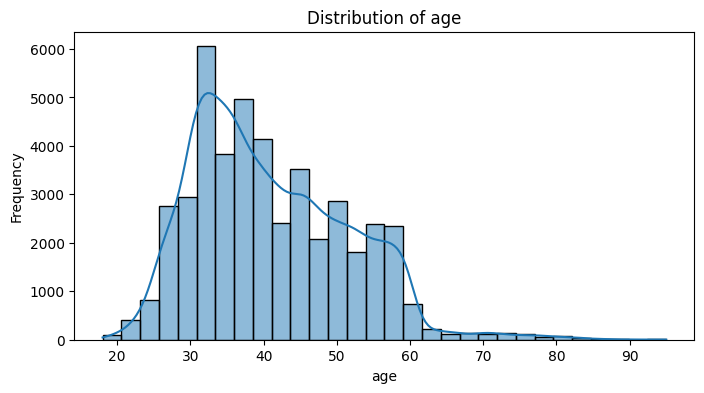

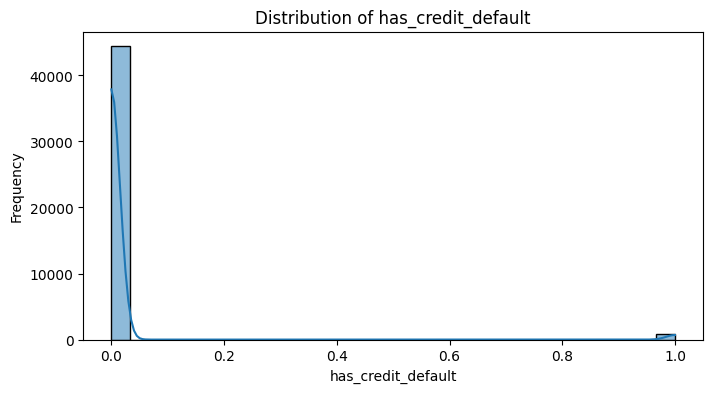

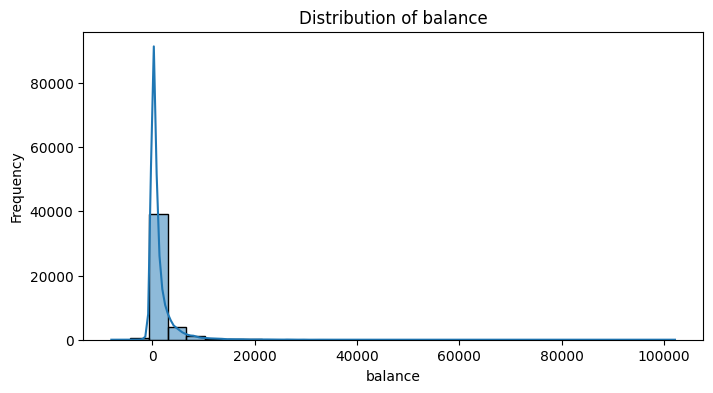

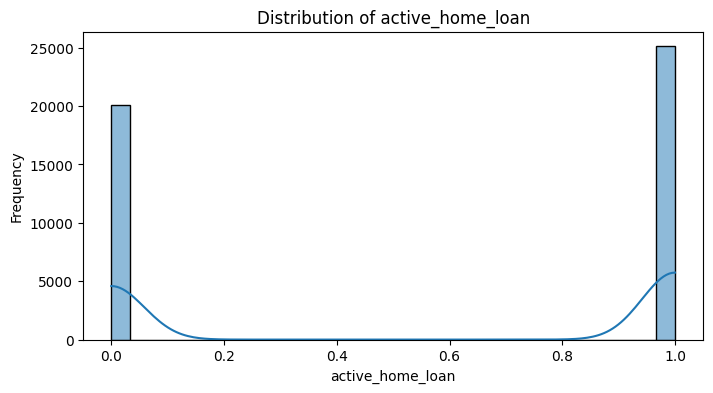

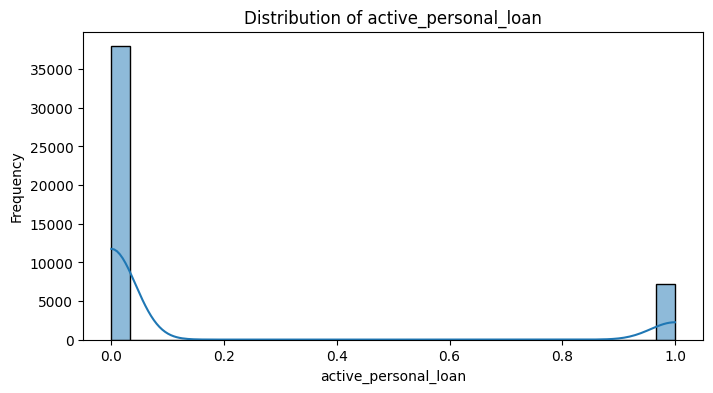

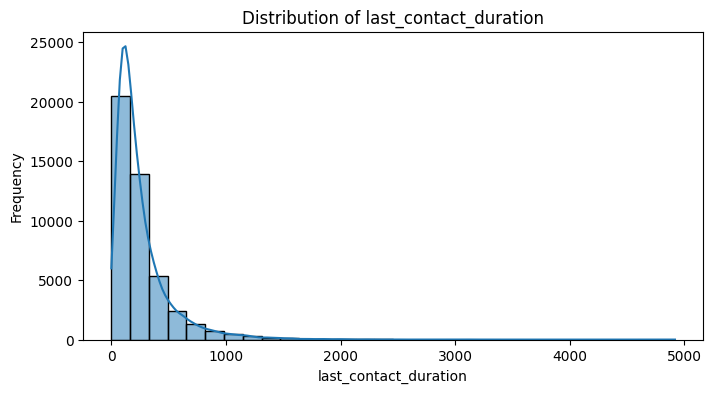

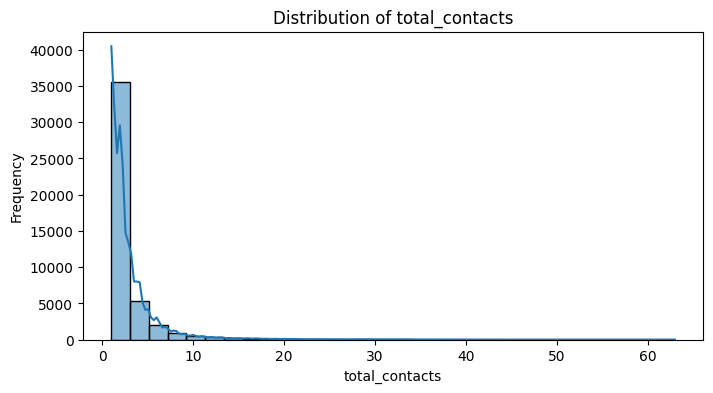

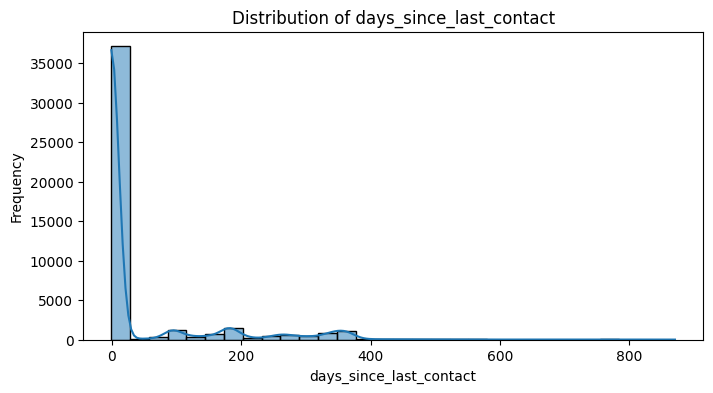

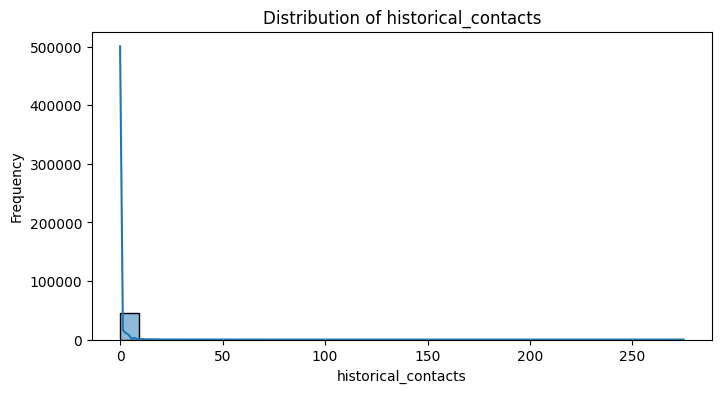

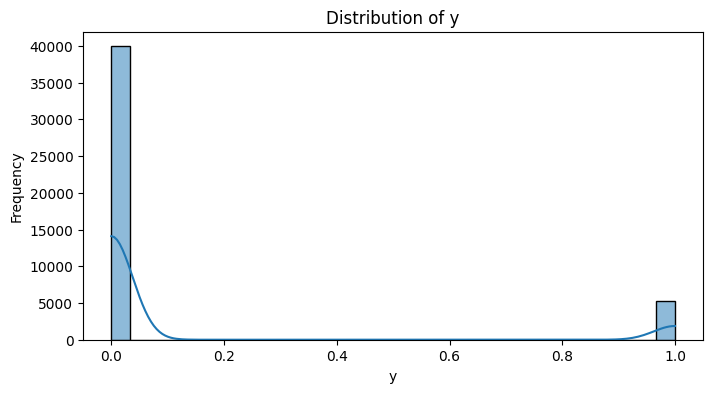

In [12]:
for col in numeric_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df[col].dropna(), bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

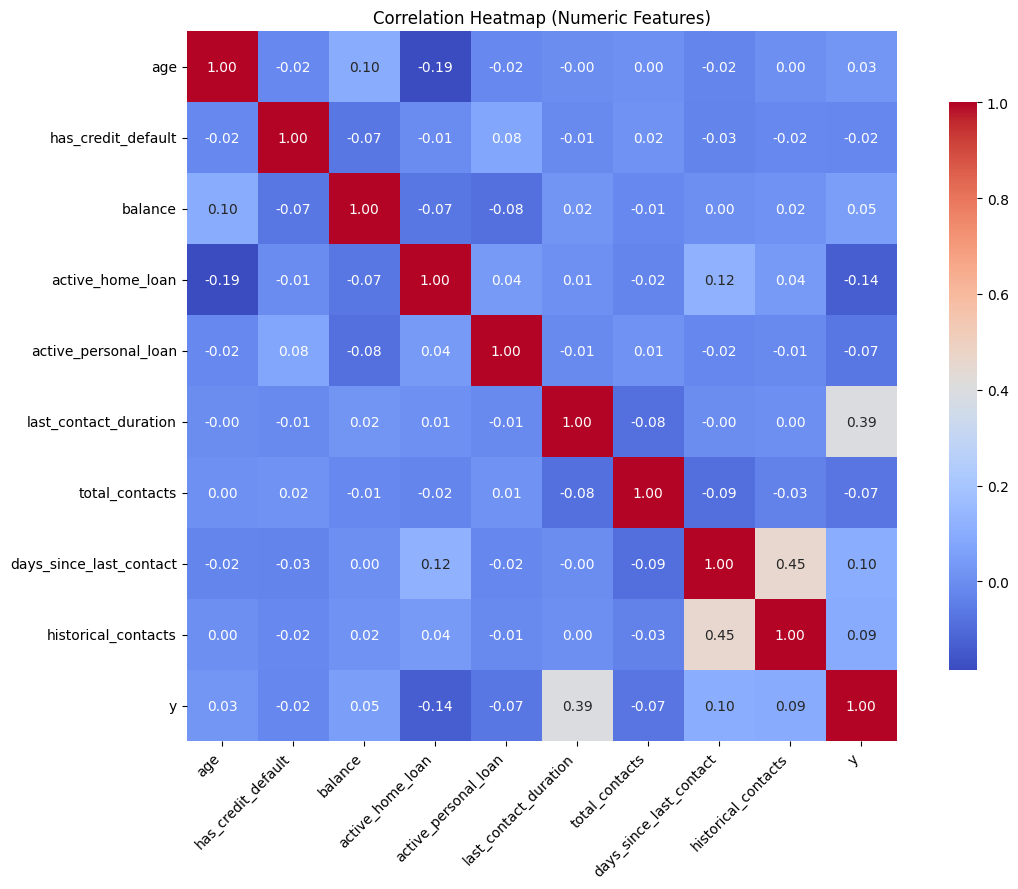

Correlation with target (y):

last_contact_duration      0.395
days_since_last_contact    0.104
historical_contacts        0.093
balance                    0.053
age                        0.025
has_credit_default        -0.022
active_personal_loan      -0.068
total_contacts            -0.073
active_home_loan          -0.139


In [13]:
corr = df[numeric_cols].corr(numeric_only=True)

plt.figure(figsize=(12, 9))
ax = sns.heatmap(
    corr,
    annot=True, fmt=".2f",
    cmap="coolwarm",
    square=True,
    cbar_kws={"shrink": 0.8}
)
ax.set_title("Correlation Heatmap (Numeric Features)")
ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Optional: sorted correlations with the target
if "y" in corr.columns:
    print("Correlation with target (y):\n")
    print(corr["y"].drop("y").sort_values(ascending=False).round(3).to_string())

In [14]:
# Drop the leakage feature safely
if "last_contact_duration" in df.columns:
    df = df.drop(columns=["last_contact_duration"])

# Recalculate numeric columns
numeric_cols = df.select_dtypes(include="number").columns

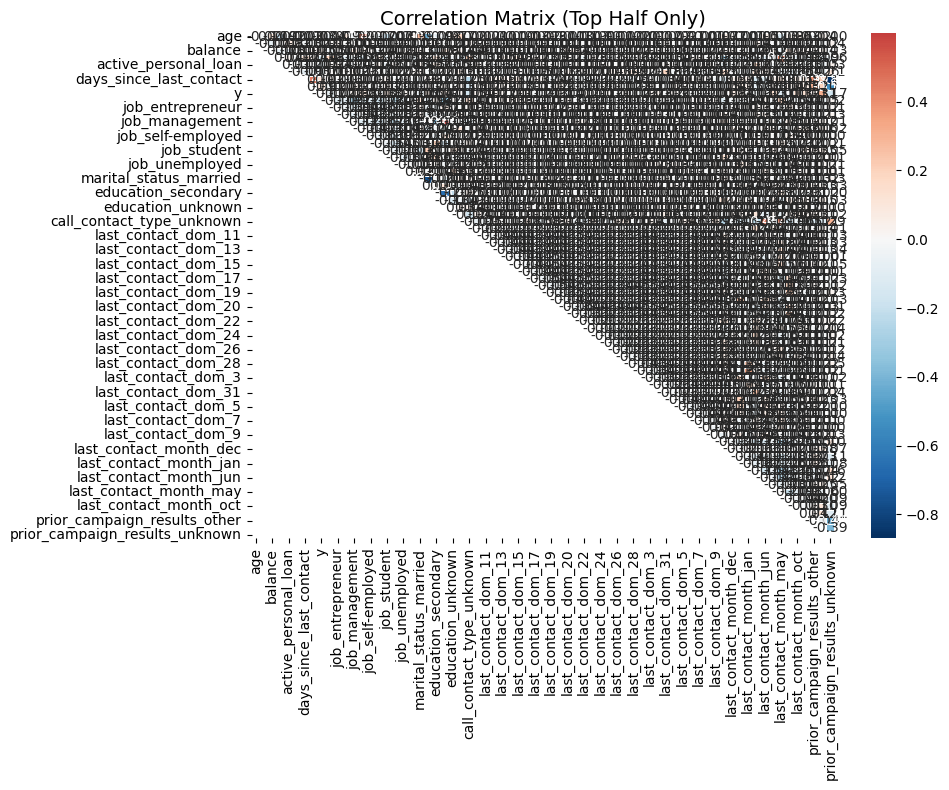

In [15]:
df = pd.get_dummies(df, columns=categorical_cols, drop_first=True, dtype=int)
    
corr = df.corr(numeric_only=True)

# mask the lower triangle
mask = np.tril(np.ones_like(corr, dtype=bool))

# set up the plot
plt.figure(figsize=(10, 8))
sns.heatmap(
    corr,
    mask=mask,
    cmap="RdBu_r",        # Red = negative, Blue = positive
    center=0,             # ensure 0 is white
    annot=True,           # show correlation values
    fmt=".2f",
    linewidths=0.5
)

plt.title("Correlation Matrix (Top Half Only)", fontsize=14)
plt.tight_layout()
plt.show()

In [16]:
for col in numeric_cols:
    # Print summary stats
    print(f"\nSummary statistics for {col}:")
    print(df[col].describe())


Summary statistics for age:
count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

Summary statistics for has_credit_default:
count    45211.000000
mean         0.018027
std          0.133049
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: has_credit_default, dtype: float64

Summary statistics for balance:
count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

Summary statistics for active_home_loan:
count    45211.000000
mean         0.555838
std          0.496878
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: active_home_loan, dtype: float64

Sum

2. Data Integrity & Structure

Q: Did you find any missing, duplicate, or incorrectly formatted entries in the dataset?

A: No missing or duplicate data - columns seemed mislabeled so I renamed for clarity

Q: Are all data types appropriate for their features (e.g., numeric, categorical)?
A: Adjusted binary yes/no to 1/0

In [17]:
def cap_series(s: pd.Series, lower_q=None, upper_q=0.99):
    """Winsorize/cap a series at given quantiles. If lower_q is None, only cap upper tail."""
    s = s.copy()
    if upper_q is not None:
        upper = s.quantile(upper_q)
        s = np.minimum(s, upper)
    if lower_q is not None:
        lower = s.quantile(lower_q)
        s = np.maximum(s, lower)
    return s

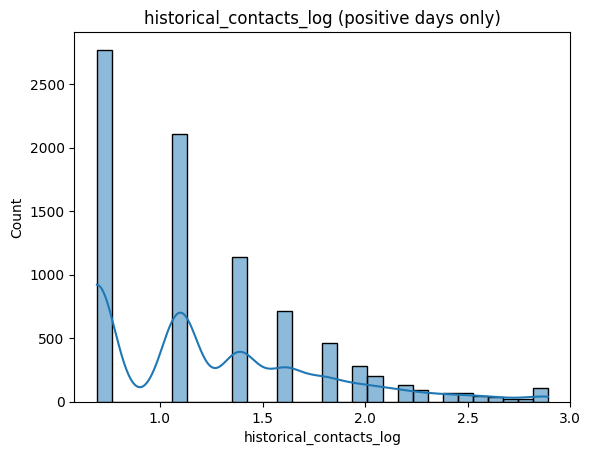

In [18]:
df_prep = df.copy()

df_prep["no_historical_contacts_flag"] = (df_prep["historical_contacts"] == 0).astype(int)

hist_pos = df_prep["historical_contacts"].where(df_prep["historical_contacts"] > 0, np.nan)
hist_pos = hist_pos.clip(upper=hist_pos.quantile(0.99))  # cap extreme outliers
df_prep["historical_contacts_log"] = np.log1p(hist_pos)

sns.histplot(df_prep["historical_contacts_log"].dropna(), bins=30, kde=True)
plt.title("historical_contacts_log (positive days only)")
plt.show()

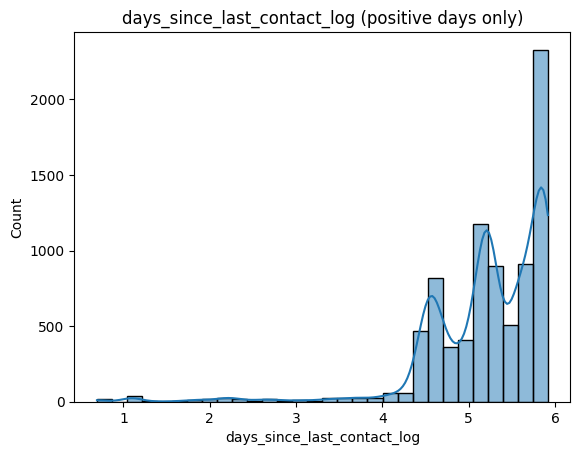

In [19]:
ds = df_prep["days_since_last_contact"]

# 1) binary flag for never-contacted
df_prep["never_contacted_flag"] = (ds == -1).astype(int)

# 2) keep ONLY positive days in the numeric feature (NaN for -1)
ds_pos = ds.where(ds >= 0, np.nan)

# cap the right tail, then log1p
ds_pos = ds_pos.clip(upper=ds_pos.quantile(0.95))
df_prep["days_since_last_contact_log"] = np.log1p(ds_pos)

sns.histplot(df_prep["days_since_last_contact_log"].dropna(), bins=30, kde=True)
plt.title("days_since_last_contact_log (positive days only)")
plt.show()

In [20]:
num_cols = []
if "age" in df_prep.columns:
    # age: keep raw
    num_cols.append("age")

# ---- balance: winsorize then log1p (with shift if negatives) ----
if "balance" in df_prep.columns:
    bal = df_prep["balance"].copy()
    # cap extremes at 1st/99th percentiles
    lower, upper = bal.quantile(0.01), bal.quantile(0.99)
    bal = bal.clip(lower, upper)
    # shift if negatives exist, then log1p
    shift = 1 - bal.min() if bal.min() <= 0 else 0
    df_prep["balance_log"] = np.log1p(bal + shift)
    num_cols.append("balance_log")

if "total_contacts" in df_prep.columns:
    # total_contacts: cap at 95th percentile (count-like)
    df_prep["total_contacts_cap"] = cap_series(df_prep["total_contacts"], upper_q=0.95)
    num_cols.append("total_contacts_cap")

# last_contact_dom (day-of-month) -> treat as categorical, not linear numeric

df_prep.head()

,age,has_credit_default,balance,active_home_loan,active_personal_loan,total_contacts,days_since_last_contact,historical_contacts,y,job_blue-collar,...,last_contact_month_sep,prior_campaign_results_other,prior_campaign_results_success,prior_campaign_results_unknown,no_historical_contacts_flag,historical_contacts_log,never_contacted_flag,days_since_last_contact_log,balance_log,total_contacts_cap
0,58,0,2143,1,0,1,-1,0,0,0,...,0,0,0,1,1,NaN,1,NaN,7.927324,1.0
1,44,0,29,1,0,1,-1,0,0,0,...,0,0,0,1,1,NaN,1,NaN,6.489205,1.0
2,33,0,2,1,1,1,-1,0,0,0,...,0,0,0,1,1,NaN,1,NaN,6.447306,1.0
3,47,0,1506,1,0,1,-1,0,0,1,...,0,0,0,1,1,NaN,1,NaN,7.666222,1.0
4,33,0,1,0,0,1,-1,0,0,0,...,0,0,0,1,1,NaN,1,NaN,6.445720,1.0


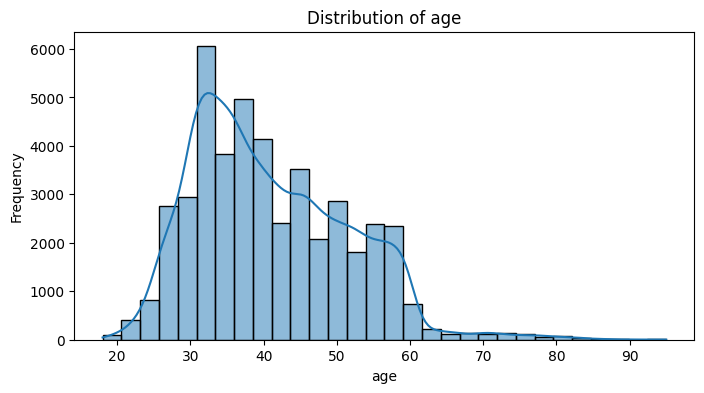

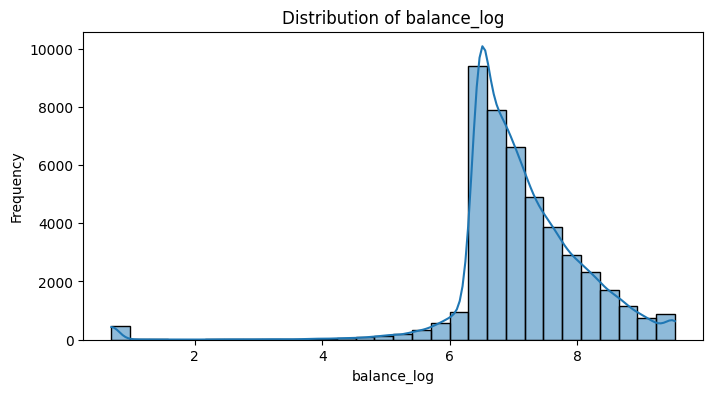

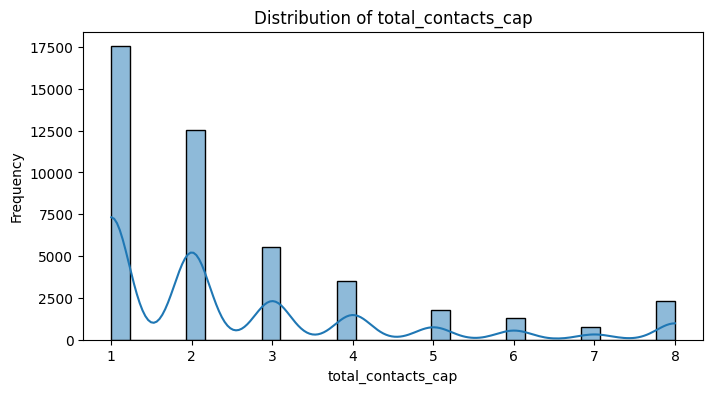

In [21]:
for col in num_cols:
    plt.figure(figsize=(8, 4))
    sns.histplot(df_prep[col].dropna(), bins=30, kde=True)
    plt.title(f"Distribution of {col}")
    plt.xlabel(col)
    plt.ylabel("Frequency")
    plt.show()

In [22]:
df_prep["recency_frequency"] = df_prep["total_contacts_cap"] / (df_prep["days_since_last_contact_log"] + 1)
df_prep["negative_balance_flag"] = (df_prep["balance"] < 0).astype(int)
df_prep["balance_per_year_age"] = df_prep["balance_log"] / (df_prep["age"] + 1)

In [23]:
df_prep.head()
print(df_prep.columns)

Index(['age', 'has_credit_default', 'balance', 'active_home_loan',
       'active_personal_loan', 'total_contacts', 'days_since_last_contact',
       'historical_contacts', 'y', 'job_blue-collar', 'job_entrepreneur',
       'job_housemaid', 'job_management', 'job_retired', 'job_self-employed',
       'job_services', 'job_student', 'job_technician', 'job_unemployed',
       'job_unknown', 'marital_status_married', 'marital_status_single',
       'education_secondary', 'education_tertiary', 'education_unknown',
       'call_contact_type_telephone', 'call_contact_type_unknown',
       'last_contact_dom_10', 'last_contact_dom_11', 'last_contact_dom_12',
       'last_contact_dom_13', 'last_contact_dom_14', 'last_contact_dom_15',
       'last_contact_dom_16', 'last_contact_dom_17', 'last_contact_dom_18',
       'last_contact_dom_19', 'last_contact_dom_2', 'last_contact_dom_20',
       'last_contact_dom_21', 'last_contact_dom_22', 'last_contact_dom_23',
       'last_contact_dom_24', 'last_con

In [24]:
# Save df_prep to CSV in the current working directory
df_prep.to_csv("model_df.csv", index=False)

print("Saved model_df.csv in working directory")

Saved model_df.csv in working directory


3. Feature Distribution & Target Assessment


Q: What did you observe about the distributions of key features (e.g., age, balance, campaign)?


A: Some features are heavily skewed and need various transform approaches


Q: Is there a class imbalance in the target variable (y)? How did you check for this?


A: Yes, will handle with scale_pos_weight for xgboost


Q: What visualizations did you use to summarize your findings?


A: Histogram distributions, bar charts and proportion bars


4. Feature Engineering


Q: What new features did you engineer (e.g., campaign frequency, time since last contact)?


A:  'recency_frequency'  -  to observe if higher contact totals insights action
    'balance_per_year_age'  -  assess financial maturity relative to age as balance alone is indicitive of action

Q: Did you identify any features to exclude or transform?


A: Excluded no recent contacts or negative days since last contact and just assigned binary flags

Q: How did you address class imbalance (e.g., SMOTE, class weights)?


A: Yes, will handle with scale_pos_weight for xgboost

In [25]:
# Select all numeric columns from df_prep dynamically
numeric_cols = df_prep.select_dtypes(include=["number"]).columns

for col in numeric_cols:
    print(f"\nSummary statistics for {col}:")
    print(df_prep[col].describe())


Summary statistics for age:
count    45211.000000
mean        40.936210
std         10.618762
min         18.000000
25%         33.000000
50%         39.000000
75%         48.000000
max         95.000000
Name: age, dtype: float64

Summary statistics for has_credit_default:
count    45211.000000
mean         0.018027
std          0.133049
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: has_credit_default, dtype: float64

Summary statistics for balance:
count     45211.000000
mean       1362.272058
std        3044.765829
min       -8019.000000
25%          72.000000
50%         448.000000
75%        1428.000000
max      102127.000000
Name: balance, dtype: float64

Summary statistics for active_home_loan:
count    45211.000000
mean         0.555838
std          0.496878
min          0.000000
25%          0.000000
50%          1.000000
75%          1.000000
max          1.000000
Name: active_home_loan, dtype: float64

Sum

Data Preprocessing & Model Development


1. Categorical Feature Encoding


Q: Which categorical features did you encode, and what encoding methods did you use (label, one-hot)?


A: All categorical features



Q: Show a sample of the encoded data.


A: See above



2. Numerical Feature Scaling


Q: Which numerical features did you scale, and which scaler did you choose (StandardScaler, MinMaxScaler)? Why?


A: Balance and total contacts, mainly capped the extreme values



Q: Show summary statistics of the scaled features.


A: See above



✂️ 3. Data Splitting
Q: How did you split the dataset into training, validation, and test sets? What proportions did you use?
A:

Q: Did you use stratification? Why or why not?
A:

🤖 4. Model Training & Evaluation
Q: Which baseline models did you train (Logistic Regression, Decision Tree, Random Forest)?
A:

Q: What metrics did you use to evaluate model performance?
A:

Q: How did you tune hyperparameters and validate your models?
A:

Q: Which model performed best, and why did you select it?
A: